## Holiday Package Prediction

### 1) What is the problem?
A travel company called "Trips & Travel.Com" wants to get more customers.

- Right now, they sell 5 types of holiday packages: **Basic, Standard, Deluxe, Super Deluxe and King**.
- Last year, only **18%** of the customers they contacted bought a package.
- They called customers randomly, so they spent a lot of money on marketing.

Now the company wants to launch a new package called **Wellness Tourism Package** (trips that help people stay healthy and feel good).

**Our goal:** Use past customer data to predict **which customers are likely to buy a package**. This way, the company only contacts the right people and saves money.

### 2) About the data
- Source: [Kaggle - Holiday Package Purchase Prediction](https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction)
- Size: **4888 rows** and **20 columns**

In [42]:
## importing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [43]:
df = pd.read_csv("travel_data.csv")
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


## Data Cleaning
Real data is often messy. Before training a model, we clean it.

In this section we will:
1. **Find missing values** - check which columns have empty cells
2. **Fix wrong categories** - for example, "Fe Male" should be "Female"
3. **Fill missing values** - put a sensible value in the empty cells
4. **Change data types** - make sure each column has the right type (for example, numbers stored as numbers, not text)
5. **Remove unused columns** - like `CustomerID`, which does not help in prediction

In [44]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [45]:
# Just to check what percentage of each column is null
features_with_na=[features for features in df.columns if df[features].isnull().sum()>=1]
for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,5), '% missing values')

Age 4.62357 % missing values
TypeofContact 0.51146 % missing values
DurationOfPitch 5.13502 % missing values
NumberOfFollowups 0.92062 % missing values
PreferredPropertyStar 0.53191 % missing values
NumberOfTrips 2.86416 % missing values
NumberOfChildrenVisiting 1.35025 % missing values
MonthlyIncome 4.76678 % missing values


#### Some columns have null values. We will handle them later.
#### First, let's check the categorical columns.

In [46]:
# Count of each gender
df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [47]:
# Count of each marital status
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [48]:
# Count of each contact type
df['TypeofContact'].value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [49]:
# Fix categories that mean the same thing
df['Gender'] = df['Gender'].replace('Fe Male', 'Female')
df['MaritalStatus'] = df['MaritalStatus'].replace('Single', 'Unmarried')

In [50]:
# Recheck the fixed columns
print(df['Gender'].value_counts(), df['MaritalStatus'].value_counts(), sep='')

Gender
Male      2916
Female    1972
Name: count, dtype: int64MaritalStatus
Married      2340
Unmarried    1598
Divorced      950
Name: count, dtype: int64


In [51]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [52]:
# Summary stats of numeric columns that have null values
df[features_with_na].select_dtypes(exclude='object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


## Filling Null Values
We fill empty cells with one of these values:
- **Median** (middle value) - for numbers that can be anything, like age or income
- **Mode** (most common value) - for text or small counts, like contact type or star rating

| Column | Fill with |
|---|---|
| Age | Median |
| TypeofContact | Mode |
| DurationOfPitch | Median |
| NumberOfFollowups | Mode |
| PreferredPropertyStar | Mode |
| NumberOfTrips | Median |
| NumberOfChildrenVisiting | Mode |
| MonthlyIncome | Median |

In [53]:
# Fill numeric columns with median
df['Age'] = df['Age'].fillna(df['Age'].median())
df['DurationOfPitch'] = df['DurationOfPitch'].fillna(df['DurationOfPitch'].median())
df['NumberOfTrips'] = df['NumberOfTrips'].fillna(df['NumberOfTrips'].median())
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())

# Fill text and small-count columns with mode
df['TypeofContact'] = df['TypeofContact'].fillna(df['TypeofContact'].mode()[0])
df['NumberOfFollowups'] = df['NumberOfFollowups'].fillna(df['NumberOfFollowups'].mode()[0])
df['PreferredPropertyStar'] = df['PreferredPropertyStar'].fillna(df['PreferredPropertyStar'].mode()[0])
df['NumberOfChildrenVisiting'] = df['NumberOfChildrenVisiting'].fillna(df['NumberOfChildrenVisiting'].mode()[0])

In [54]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [55]:
df.drop('CustomerID', inplace=True, axis=1)


## Feature Engineering
Here we make our columns more useful for the model.

### 1) Create a new column
Look carefully at these two columns:
- `NumberOfPersonVisiting` - adults going on the trip
- `NumberOfChildrenVisiting` - children going on the trip

If you think about it, both are telling us the same thing: **how many people are going on the trip**.
In real life, a travel company doesn't care much about adults and children separately. They care about the **total group size**.

So we add them together into one column called `TotalVisiting`, and remove the two old columns.

### 2) Group the columns
We also split the columns into types: numerical, categorical, discrete and continuous.

In [56]:
df.dtypes

ProdTaken                     int64
Age                         float64
TypeofContact                   str
CityTier                      int64
DurationOfPitch             float64
Occupation                      str
Gender                          str
NumberOfPersonVisiting        int64
NumberOfFollowups           float64
ProductPitched                  str
PreferredPropertyStar       float64
MaritalStatus                   str
NumberOfTrips               float64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting    float64
Designation                     str
MonthlyIncome               float64
dtype: object

In [57]:
# Combine adults and children into one column, then remove the old columns
df['TotalVisiting'] = df['NumberOfPersonVisiting'] + df['NumberOfChildrenVisiting']
df = df.drop(columns=['NumberOfPersonVisiting', 'NumberOfChildrenVisiting'])

In [58]:
# Columns that store numbers
num_features = df.select_dtypes(include='number').columns
print(f'Num of Numerical Features : {len(num_features)}')

Num of Numerical Features : 12


In [59]:
# Columns that store text
cat_features = df.select_dtypes(exclude='number').columns
print(f'Num of Categorical Features : {len(cat_features)}')

Num of Categorical Features : 6


In [60]:
# Discrete = numeric columns with only a few unique values (like number of trips: 1, 2, 3...)
# Here, a column with 25 or fewer unique values is treated as discrete
discrete_features=[feature for feature in num_features if len(df[feature].unique())<=25]
print(f"Features = {discrete_features}")
print(f'Num of Discrete Features : {len(discrete_features)}')

Features = ['ProdTaken', 'CityTier', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'TotalVisiting']
Num of Discrete Features : 9


In [61]:
# Continuous = numeric columns with many different values (like monthly income or age)
# Here, every numeric column that is not discrete is treated as continuous
continuous_features=[feature for feature in num_features if feature not in discrete_features]
print(f"Features = {continuous_features}")
print(f'Num of Continuous Features : {len(continuous_features)}')

Features = ['Age', 'DurationOfPitch', 'MonthlyIncome']
Num of Continuous Features : 3


In [62]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


## Train Test Split And Model Training

In [63]:
from sklearn.model_selection import train_test_split
X = df.drop(['ProdTaken'], axis=1)
y = df['ProdTaken']

In [64]:
X.head()

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [65]:
y.value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [66]:
X.head()

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [67]:
# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training rows : {len(X_train)}')
print(f'Testing rows : {len(X_test)}')

Training rows : 3910
Testing rows : 978


In [68]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     4888 non-null   float64
 1   TypeofContact           4888 non-null   str    
 2   CityTier                4888 non-null   int64  
 3   DurationOfPitch         4888 non-null   float64
 4   Occupation              4888 non-null   str    
 5   Gender                  4888 non-null   str    
 6   NumberOfFollowups       4888 non-null   float64
 7   ProductPitched          4888 non-null   str    
 8   PreferredPropertyStar   4888 non-null   float64
 9   MaritalStatus           4888 non-null   str    
 10  NumberOfTrips           4888 non-null   float64
 11  Passport                4888 non-null   int64  
 12  PitchSatisfactionScore  4888 non-null   int64  
 13  OwnCar                  4888 non-null   int64  
 14  Designation             4888 non-null   str    
 15

In [69]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Separate text columns and number columns
cat_features = X.select_dtypes(exclude='number').columns
num_features = X.select_dtypes(include='number').columns

# Text columns -> convert to numbers (OneHotEncoder)
# Number columns -> bring to the same scale (StandardScaler)
preprocessor = ColumnTransformer(
    [
        # drop='first' removes one extra column per category, as it can be guessed from the others
        # Example: Gender has Female and Male -> we keep only Gender_Male
        #   Gender_Male = 1 means Male, Gender_Male = 0 means Female
        ("OneHotEncoder", OneHotEncoder(drop='first'), cat_features),
        # StandardScaler is not needed for decision trees (or random forest), as they only compare values, scale does not matter
        # We still use it because Logistic Regression is also trained below, and it needs scaled data
        ("StandardScaler", StandardScaler(), num_features)
    ]
)

In [70]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OneHotEncoder', ...), ('StandardScaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name``

In [71]:
# fit_transform on training data: learn the values (like mean) and apply the changes
X_train = preprocessor.fit_transform(X_train)

In [72]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-1.020350,1.284279,-0.725271,-0.127737,-0.632399,0.679690,0.782966,-0.382245,-0.774151
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,-0.721400,0.690023,0.282777,-0.725271,1.511598,-0.632399,0.679690,0.782966,-0.459799,0.643615
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-1.020350,0.282777,1.771041,0.418708,-0.632399,0.679690,0.782966,-0.245196,-0.065268
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,-0.721400,-1.020350,1.284279,-0.725271,-0.127737,-0.632399,1.408395,-1.277194,0.213475,-0.065268
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,2.400396,-1.720227,-0.725271,1.511598,-0.632399,-0.049015,-1.277194,-0.024889,2.061382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3905,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-0.653841,1.284279,-0.725271,-0.674182,-0.632399,-1.506426,0.782966,-0.536973,0.643615
3906,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.455047,-0.898180,-0.718725,1.771041,-1.220627,-0.632399,1.408395,0.782966,1.529609,-0.065268
3907,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.455047,1.545210,0.282777,-0.725271,2.058043,-0.632399,-0.777720,0.782966,-0.360576,0.643615
3908,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.455047,1.789549,1.284279,-0.725271,-0.127737,-0.632399,-1.506426,0.782966,-0.252799,0.643615


In [73]:
# transform on test data: use the values learned from training data (no fit here)
# Test data should stay unseen, so we don't learn anything from it
X_test = preprocessor.transform(X_test)

In [74]:
X_test

array([[ 0.        ,  0.        ,  0.        , ..., -1.2771941 ,
        -0.73751038, -0.77415132],
       [ 1.        ,  0.        ,  0.        , ..., -1.2771941 ,
        -0.6704111 , -0.06526803],
       [ 1.        ,  0.        ,  0.        , ...,  0.78296635,
        -0.4208322 , -0.77415132],
       ...,
       [ 0.        ,  1.        ,  0.        , ...,  0.78296635,
         0.69001249,  0.64361526],
       [ 1.        ,  0.        ,  0.        , ...,  0.78296635,
        -0.22827818, -0.77415132],
       [ 1.        ,  1.        ,  0.        , ...,  0.78296635,
        -0.44611323,  2.06138184]], shape=(978, 26))

## Model Training

In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 

In [76]:
# Settings we want to try for Random Forest, to find the best combination
rf_params = {
    "max_depth": [5, 8, 10, 15, None],          # How deep each tree can grow (None = no limit)
    "max_features": [5, 7, 8, "sqrt"],          # How many columns each tree looks at while splitting
    "min_samples_split": [2, 8, 15, 20],        # Minimum rows needed to split a node
    "n_estimators": [100, 200, 500, 1000]       # Number of trees in the forest
}

# Settings we want to try for Logistic Regression
lr_params = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],        # Lower C = simpler model, higher C = fits the data more closely
    "solver": ["lbfgs", "liblinear", "newton-cg"],  # Method used to find the best weights
    "max_iter": [100, 500, 1000],               # How many steps the solver can take to finish learning
    "class_weight": [None, "balanced"]          # "balanced" gives more importance to the smaller class (buyers)
}

# Settings we want to try for Decision Tree
dt_params = {
    "criterion": ["gini", "entropy", "log_loss"],   # How the tree measures a good split
    "max_depth": [3, 5, 8, 10, 15, None],           # How deep the tree can grow (None = no limit)
    "min_samples_split": [2, 8, 15, 20],            # Minimum rows needed to split a node
    "min_samples_leaf": [1, 2, 5, 10],              # Minimum rows that must end up in each leaf
    "max_features": [5, 7, 8, "sqrt", None]         # How many columns the tree looks at while splitting
}

# Settings we want to try for Gradient Boosting
gb_params = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2],    # How much each new tree corrects the previous ones
    "n_estimators": [100, 200, 500],            # Number of trees built one after another
    "max_depth": [3, 5, 8, 10],                 # How deep each tree can grow
    "subsample": [0.6, 0.8, 1.0],               # Fraction of rows each tree learns from
    "min_samples_split": [2, 8, 15, 20]         # Minimum rows needed to split a node
}

# Settings we want to try for AdaBoost
#
# How AdaBoost works:
#   It builds small trees one after another. After each tree, the rows it got wrong get a higher weight,
#   so the next tree focuses more on those hard rows. At the end, every tree votes, and better trees get a bigger say.
#
# learning_rate:
#   Every tree's say (its vote weight) is multiplied by the learning_rate.
#   - learning_rate = 1.0  -> each tree has its full say, so the model learns fast (but can overfit)
#   - learning_rate = 0.1  -> each tree has only 10% of its say, so the model learns slowly and carefully
#   A small learning_rate usually needs more trees (higher n_estimators) to reach the same accuracy.
#
# algorithm ('SAMME' vs 'SAMME.R'):
#   - 'SAMME'   : uses only the final answer of each tree (buy / not buy).
#                 A tree's vote weight depends on how many rows it got wrong.
#   - 'SAMME.R' : ("R" = Real) uses the probability of each tree (for example, 80% sure the customer will buy).
#                 It usually learned faster, because a probability carries more information than a plain yes/no.
#   Note: scikit-learn removed 'SAMME.R' (version 1.6) and then the whole algorithm setting (version 1.8).
#   AdaBoostClassifier now always uses 'SAMME', so we can't add "algorithm" to the settings below.
#   On older versions you could try: "algorithm": ["SAMME", "SAMME.R"]
ada_params = {
    "n_estimators": [50, 70, 100, 120, 150, 200],   # Number of small trees built one after another
    "learning_rate": [0.001, 0.01, 0.1, 0.5, 1.0]   # How much say each tree gets in the final vote (lower = slower, careful learning)
}

In [77]:
rf_params

{'max_depth': [5, 8, 10, 15, None],
 'max_features': [5, 7, 8, 'sqrt'],
 'min_samples_split': [2, 8, 15, 20],
 'n_estimators': [100, 200, 500, 1000]}

In [78]:
# List of models to tune: (short name, model, settings to try)
randomcv_models = [
    ("LR", LogisticRegression(), lr_params),
    ("DT", DecisionTreeClassifier(), dt_params),
    ("RF", RandomForestClassifier(), rf_params),
    ("GB", GradientBoostingClassifier(), gb_params),
    ("ADA", AdaBoostClassifier(), ada_params)
]

In [79]:
randomcv_models

[('LR',
  LogisticRegression(),
  {'C': [0.001, 0.01, 0.1, 1, 10, 100],
   'solver': ['lbfgs', 'liblinear', 'newton-cg'],
   'max_iter': [100, 500, 1000],
   'class_weight': [None, 'balanced']}),
 ('DT',
  DecisionTreeClassifier(),
  {'criterion': ['gini', 'entropy', 'log_loss'],
   'max_depth': [3, 5, 8, 10, 15, None],
   'min_samples_split': [2, 8, 15, 20],
   'min_samples_leaf': [1, 2, 5, 10],
   'max_features': [5, 7, 8, 'sqrt', None]}),
 ('RF',
  RandomForestClassifier(),
  {'max_depth': [5, 8, 10, 15, None],
   'max_features': [5, 7, 8, 'sqrt'],
   'min_samples_split': [2, 8, 15, 20],
   'n_estimators': [100, 200, 500, 1000]}),
 ('GB',
  GradientBoostingClassifier(),
  {'learning_rate': [0.01, 0.05, 0.1, 0.2],
   'n_estimators': [100, 200, 500],
   'max_depth': [3, 5, 8, 10],
   'subsample': [0.6, 0.8, 1.0],
   'min_samples_split': [2, 8, 15, 20]}),
 ('ADA',
  AdaBoostClassifier(),
  {'n_estimators': [50, 70, 100, 120, 150, 200],
   'learning_rate': [0.001, 0.01, 0.1, 0.5, 1.0]})

In [80]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}

for name, model, params in randomcv_models:
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=100,     # Try 100 random combinations
        cv=3,           # Check each combination 3 times on different parts of the data
        verbose=2,      # Show progress while running
        n_jobs=-1       # Use all CPU cores to run faster
    )
    search.fit(X_train, y_train)
    model_param[name] = search.best_params_

# Show the best settings for each model
for model_name in model_param:
    print(f"---------------- Best Params for {model_name} ----------------")
    print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
---------------- Best Params for LR ----------------
{'solver': 'lbfgs', 'max_iter': 1000, 'class_weight': None, 'C': 0.1}
---------------- Best Params for DT ----------------
{'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 10, 'criterion': 'gini'}
---------------- Best Params for RF ----------------
{'n_estimators': 1000, 'min_samples_split': 2, 'max_features': 8, 'max_depth': None}
---------------- Best Params for GB ----------------
{'subsample': 1.0, 'n_estimators': 500, 'min_samples_split': 20, 'max_depth': 10, 'learning_rate': 0.2}
---------------- Best Params for ADA ----------------
{'n_estimators': 120, 'learning_rate': 1.0}


Logistic Regression
Training set:
- Accuracy  : 0.8448
- Precision : 0.7089
- Recall    : 0.2840
- F1 score  : 0.8165
- ROC AUC   : 0.6286
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      3181
           1       0.71      0.28      0.41       729

    accuracy                           0.84      3910
   macro avg       0.78      0.63      0.66      3910
weighted avg       0.83      0.84      0.82      3910



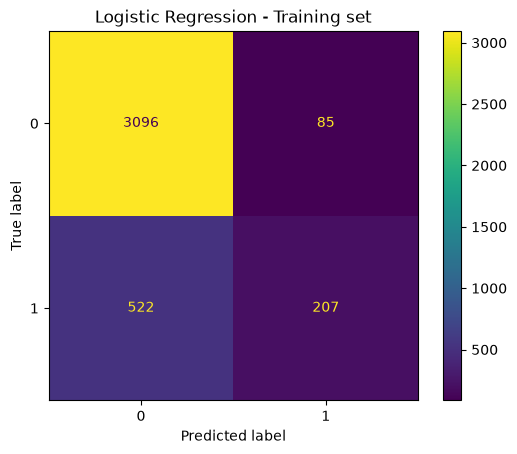

Test set:
- Accuracy  : 0.8384
- Precision : 0.7143
- Recall    : 0.2880
- F1 score  : 0.8095
- ROC AUC   : 0.6300
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       787
           1       0.71      0.29      0.41       191

    accuracy                           0.84       978
   macro avg       0.78      0.63      0.66       978
weighted avg       0.82      0.84      0.81       978



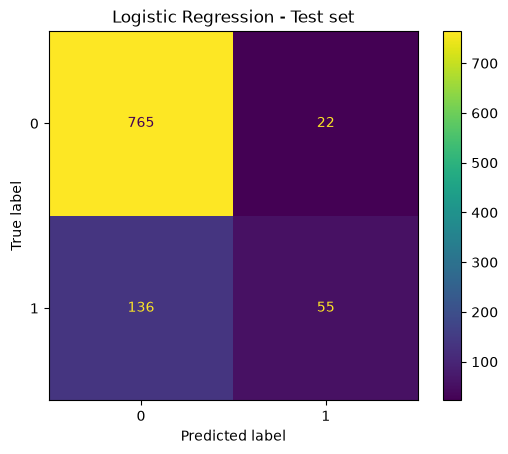


Decision Tree
Training set:
- Accuracy  : 1.0000
- Precision : 1.0000
- Recall    : 1.0000
- F1 score  : 1.0000
- ROC AUC   : 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3181
           1       1.00      1.00      1.00       729

    accuracy                           1.00      3910
   macro avg       1.00      1.00      1.00      3910
weighted avg       1.00      1.00      1.00      3910



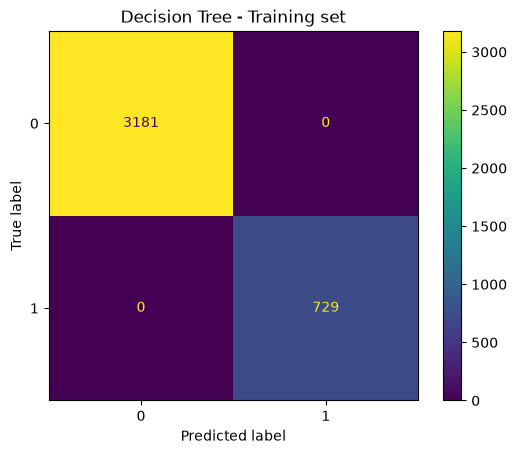

Test set:
- Accuracy  : 0.9192
- Precision : 0.8256
- Recall    : 0.7435
- F1 score  : 0.9176
- ROC AUC   : 0.8527
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       787
           1       0.83      0.74      0.78       191

    accuracy                           0.92       978
   macro avg       0.88      0.85      0.87       978
weighted avg       0.92      0.92      0.92       978



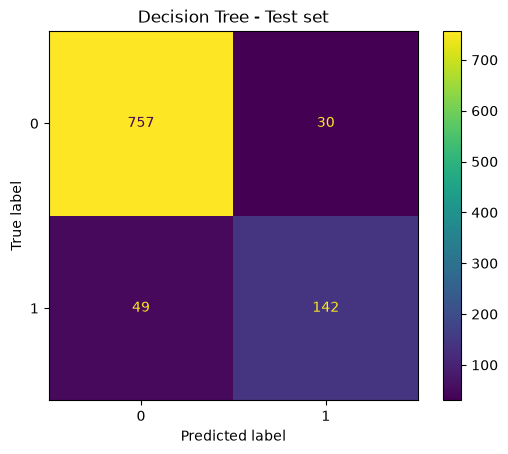


Random Forest
Training set:
- Accuracy  : 1.0000
- Precision : 1.0000
- Recall    : 1.0000
- F1 score  : 1.0000
- ROC AUC   : 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3181
           1       1.00      1.00      1.00       729

    accuracy                           1.00      3910
   macro avg       1.00      1.00      1.00      3910
weighted avg       1.00      1.00      1.00      3910



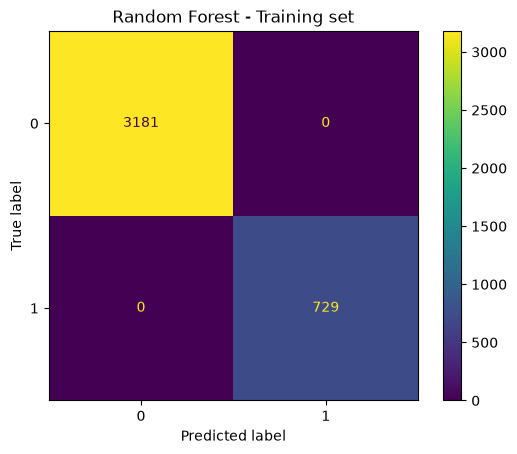

Test set:
- Accuracy  : 0.9376
- Precision : 0.9710
- Recall    : 0.7016
- F1 score  : 0.9336
- ROC AUC   : 0.8482
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       787
           1       0.97      0.70      0.81       191

    accuracy                           0.94       978
   macro avg       0.95      0.85      0.89       978
weighted avg       0.94      0.94      0.93       978



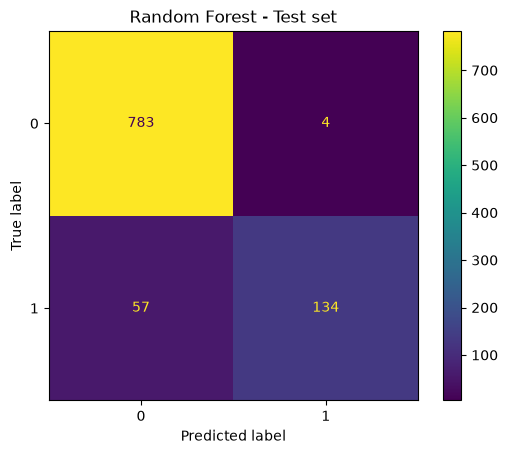


Gradient Boost
Training set:
- Accuracy  : 1.0000
- Precision : 1.0000
- Recall    : 1.0000
- F1 score  : 1.0000
- ROC AUC   : 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3181
           1       1.00      1.00      1.00       729

    accuracy                           1.00      3910
   macro avg       1.00      1.00      1.00      3910
weighted avg       1.00      1.00      1.00      3910



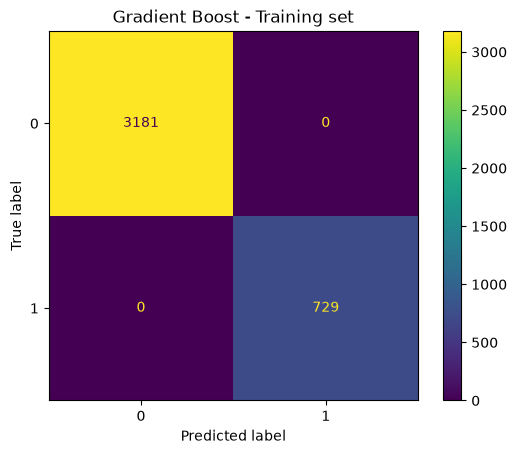

Test set:
- Accuracy  : 0.9581
- Precision : 0.9688
- Recall    : 0.8115
- F1 score  : 0.9566
- ROC AUC   : 0.9026
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       787
           1       0.97      0.81      0.88       191

    accuracy                           0.96       978
   macro avg       0.96      0.90      0.93       978
weighted avg       0.96      0.96      0.96       978



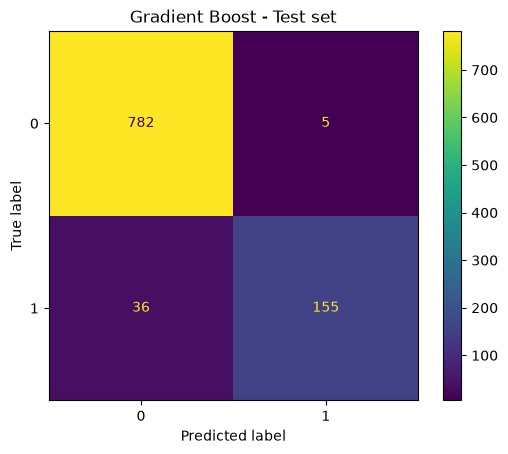


AdaBoost
Training set:
- Accuracy  : 0.8519
- Precision : 0.7679
- Recall    : 0.2949
- F1 score  : 0.8239
- ROC AUC   : 0.6372
              precision    recall  f1-score   support

           0       0.86      0.98      0.91      3181
           1       0.77      0.29      0.43       729

    accuracy                           0.85      3910
   macro avg       0.81      0.64      0.67      3910
weighted avg       0.84      0.85      0.82      3910



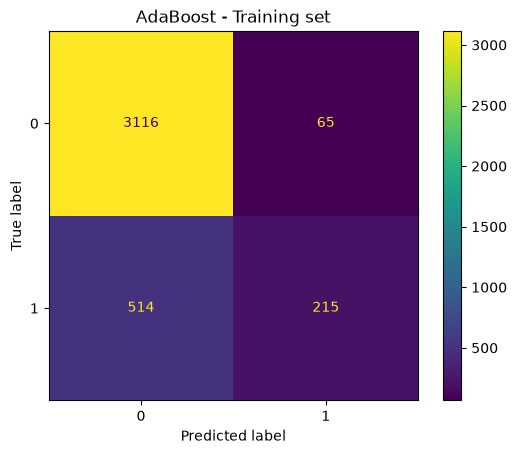

Test set:
- Accuracy  : 0.8344
- Precision : 0.7164
- Recall    : 0.2513
- F1 score  : 0.8006
- ROC AUC   : 0.6136
              precision    recall  f1-score   support

           0       0.84      0.98      0.90       787
           1       0.72      0.25      0.37       191

    accuracy                           0.83       978
   macro avg       0.78      0.61      0.64       978
weighted avg       0.82      0.83      0.80       978



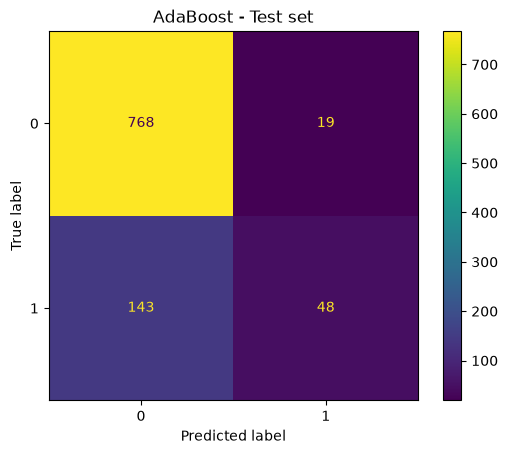

In [81]:
# Models we want to compare, this time using the best settings we found above
models = {
    "Logistic Regression": LogisticRegression(
        solver="newton-cg",
        max_iter=1000,
        class_weight=None,
        C=0.1
    ),
    "Decision Tree": DecisionTreeClassifier(
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=None,
        max_depth=None,
        criterion="gini"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        min_samples_split=2,
        max_features=8,
        max_depth=None
    ),
    "Gradient Boost": GradientBoostingClassifier(
        subsample=1.0,
        n_estimators=500,
        min_samples_split=15,
        max_depth=10,
        learning_rate=0.1
    ),
    # AdaBoost uses the best settings stored in model_param by the search above
    "AdaBoost": AdaBoostClassifier(
        n_estimators=model_param["ADA"]["n_estimators"],
        learning_rate=model_param["ADA"]["learning_rate"]
    ),
}

# Prints all the scores by comparing real answers with predicted answers
def print_scores(y_true, y_pred, title):
    # Accuracy: out of all customers, how many did the model predict correctly
    print(f"- Accuracy  : {accuracy_score(y_true, y_pred):.4f}")

    # Precision: out of customers the model said WILL buy, how many actually bought
    print(f"- Precision : {precision_score(y_true, y_pred):.4f}")

    # Recall: out of customers who actually bought, how many did the model find
    print(f"- Recall    : {recall_score(y_true, y_pred):.4f}")

    # F1 score: one number that balances precision and recall
    print(f"- F1 score  : {f1_score(y_true, y_pred, average='weighted'):.4f}")

    # ROC AUC: how well the model separates buyers from non-buyers
    # 0.5 = no better than random guessing, 1.0 = perfect
    print(f"- ROC AUC   : {roc_auc_score(y_true, y_pred):.4f}")

    # Classification report: precision, recall and f1 score for each class (0 = not buy, 1 = buy)
    print(classification_report(y_true, y_pred))

    # Confusion matrix: counts of correct and wrong predictions for each class
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
    plt.title(title)
    plt.show()

# Train each model and check how well it does
for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print(name)
    print("Training set:")
    print_scores(y_train, y_train_pred, f"{name} - Training set")

    print("Test set:")
    print_scores(y_test, y_test_pred, f"{name} - Test set")

    print("=" * 35)
    print()

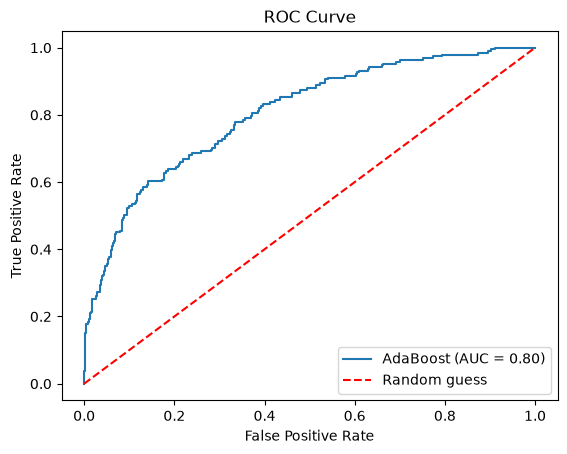

In [82]:
from sklearn.metrics import roc_auc_score, roc_curve

# Use the AdaBoost model trained above with best params
model = models["AdaBoost"]
y_test_prob = model.predict_proba(X_test)[:, 1]   # Probability of buying
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
auc = roc_auc_score(y_test, y_test_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AdaBoost (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], "r--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.savefig("auc.png")
plt.show()